# 11. Idiomas por persona

**Fuente:** `data/raw/idiomaspersonas.csv`  
**Salida:** `data/processed/idiomas_personas.csv`

Nivel de idiomas (lectura, escritura, comprension, conversacion) declarado por cada persona. El archivo de origen duplica IDPERSONA/IDIDIOMA/ULTIMO_CAMBIO/VERSION por un join previo; se colapsan antes de limpiar.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('idiomaspersonas.csv', low_memory=False)
df.head()

Leido idiomaspersonas.csv con encoding=utf-8-sig -> 4137 filas, 20 columnas


,IDPERSONA,IDIDIOMA,IDIOMA,ULTIMO_CAMBIO,VERSION,IDIDIOMAPERSONA,IDPERSONA.1,IDIDIOMA.1,NIVELLECTURA,NIVELESCRITURA,NIVELCOMPRESION,NIVELCONVERSACION,ULTIMO_CAMBIO.1,VERSION.1,NAMEARCHDOC,DESCRIPCION,REFARCHIVO,LENGUANATIVA,NIVELMCER,FECHASUBIDAARCHIVO
0,26,2,INGLES,2006-05-30-12.44.15.284836,1,491,26,2,I,I,NaN,I,2015-11-20-18.57.49.498542,1,IDI0102921053-2.PDF,NaN,"561,525",NaN,NaN,NaN
1,38,6,FRANCES,2006-06-07-15.27.51.941263,1,3125,38,6,I,I,B,A,2021-04-22-14.35.40.084590,1,NaN,NaN,NaN,S,NaN,NaN
2,38,2,INGLES,2006-05-30-12.44.15.284836,1,3127,38,2,I,I,B,I,2021-04-22-14.36.02.893052,1,NaN,NaN,NaN,S,NaN,NaN
3,86,3,PORTUGUES,2006-05-30-12.46.53.950442,1,777,86,3,A,A,NaN,A,2016-05-25-11.28.08.510614,1,NaN,NaN,"44703,43837",NaN,NaN,NaN
4,94,2,INGLES,2006-05-30-12.44.15.284836,1,352,94,2,A,A,NaN,I,2016-10-20-11.32.48.470390,1,IDI0602157588-2.PDF,NaN,"463,438",N,NaN,NaN


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'idiomas_personas')

--- Resumen idiomas_personas ---
Dimensiones: 4137 filas x 20 columnas
Filas duplicadas: 0
Columnas con nulos (%):
DESCRIPCION           99.2
FECHASUBIDAARCHIVO    94.1
NAMEARCHDOC           91.6
NIVELMCER             84.6
REFARCHIVO            72.4
NIVELCOMPRESION       46.7
LENGUANATIVA           8.0
dtype: float64


In [4]:
df.dtypes

IDPERSONA              int64
IDIDIOMA               int64
IDIOMA                object
ULTIMO_CAMBIO         object
VERSION                int64
IDIDIOMAPERSONA        int64
IDPERSONA.1            int64
IDIDIOMA.1             int64
NIVELLECTURA          object
NIVELESCRITURA        object
NIVELCOMPRESION       object
NIVELCONVERSACION     object
ULTIMO_CAMBIO.1       object
VERSION.1              int64
NAMEARCHDOC           object
DESCRIPCION           object
REFARCHIVO            object
LENGUANATIVA          object
NIVELMCER             object
FECHASUBIDAARCHIVO    object
dtype: object

## 3. Limpieza

In [7]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_duplicadas(df)
df = pc.quitar_columnas_vacias(df, umbral=0.90)
df = pc.quitar_columnas_constantes(df)
df = df.drop(columns=['ULTIMO_CAMBIO', 'REFARCHIVO'], errors='ignore')

## 5. Tipado de fechas e identificadores

In [8]:
df = pc.castear_fechas(df, ['ULTIMO_CAMBIO', 'FECHASUBIDAARCHIVO'])
df = pc.castear_enteros(df, ['IDPERSONA', 'IDIDIOMA', 'IDIDIOMAPERSONA'])
df = pc.convertir_sn_a_binario(df, ['LENGUANATIVA'])

Columnas S/N convertidas a binario (1/0): ['LENGUANATIVA']


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Idiomas más declarados** por el personal.

<Axes: title={'center': 'Idiomas más declarados'}, ylabel='IDIOMA'>

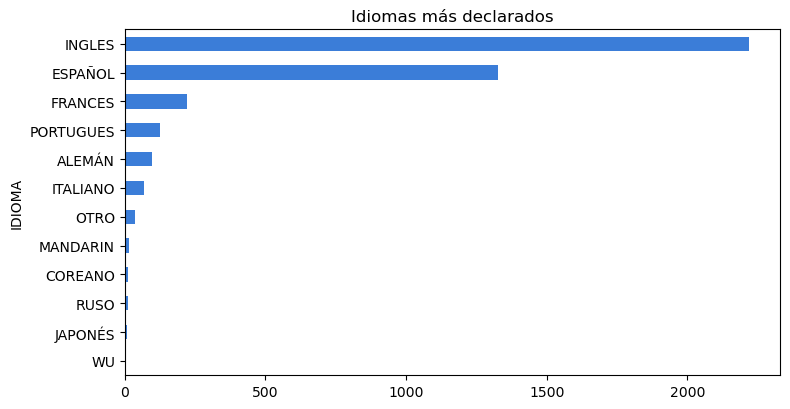

In [ ]:
pc.grafico_barras(df['IDIOMA'], 'Idiomas más declarados', top=12)

**Nivel MCER declarado** (cuando está disponible).

<Axes: title={'center': 'Distribución de NIVELMCER'}, xlabel='NIVELMCER'>

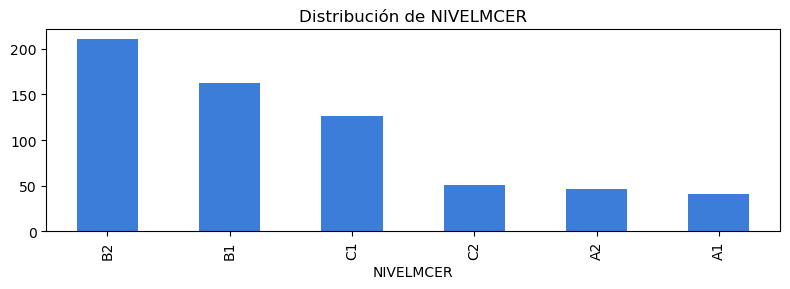

In [10]:
pc.grafico_barras(df['NIVELMCER'], 'Distribución de NIVELMCER', top=6, horizontal=False)

**Nivel de lectura declarado**.

<Axes: title={'center': 'Distribución de NIVELLECTURA'}, xlabel='NIVELLECTURA'>

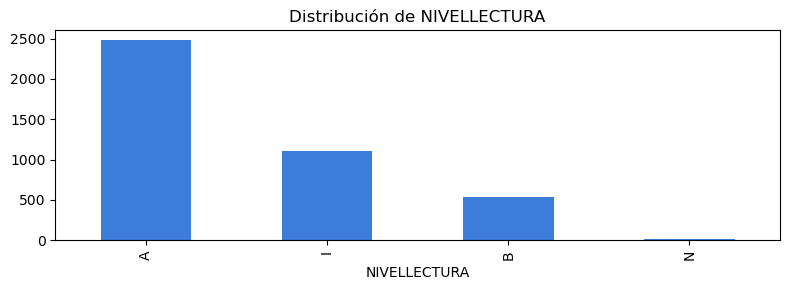

In [11]:
pc.grafico_barras(df['NIVELLECTURA'], 'Distribución de NIVELLECTURA', horizontal=False)

**Lengua nativa** (LENGUANATIVA, ya convertida a binario).

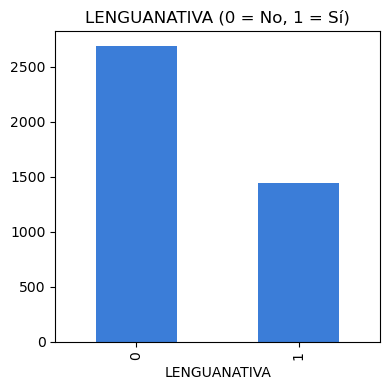

In [12]:
conteo_lengua = df['LENGUANATIVA'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 4))
conteo_lengua.plot(kind='bar', ax=ax, color=pc.COLOR_PRINCIPAL)
ax.set_title('LENGUANATIVA (0 = No, 1 = Sí)')
plt.tight_layout()

## 7. Verificación final

In [13]:
pc.resumen(df, 'idiomas_personas (procesado)')
df.head()

--- Resumen idiomas_personas (procesado) ---
Dimensiones: 4137 filas x 9 columnas
Filas duplicadas: 0
Columnas con nulos (%):
NIVELMCER    84.6
dtype: float64


,IDPERSONA,IDIDIOMA,IDIOMA,IDIDIOMAPERSONA,NIVELLECTURA,NIVELESCRITURA,NIVELCONVERSACION,LENGUANATIVA,NIVELMCER
0,26,2,INGLES,491,I,I,I,0,<NA>
1,38,6,FRANCES,3125,I,I,A,1,<NA>
2,38,2,INGLES,3127,I,I,I,1,<NA>
3,86,3,PORTUGUES,777,A,A,A,0,<NA>
4,94,2,INGLES,352,A,A,I,0,<NA>


## 8. Guardado en data/processed

In [ ]:
pc.guardar_procesado(df, 'idiomas_personas.csv')

Guardado: D:\Proyecto_Tesis\data\processed\idiomas_personas.csv (4137 filas x 13 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/idiomas_personas.csv')